In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import jax
import jax.numpy as jnp
from typing import List, Tuple, Union, Callable

import kernels
import integrator
import core

from importlib import reload

kernels = reload(kernels)
integrator = reload(integrator)
core = reload(core)

In [2]:
def logistic_map(x: jnp.ndarray, r: float = 3.5) -> jnp.ndarray:
    return r*x*(1-x)

In [3]:
f = lambda x: logistic_map(x, r=4.0)

In [4]:
df = pd.read_csv('datasets/logistic_ver_2_noise_0_02.csv')
df = df.loc[df['cluster'] == 0].drop('cluster', axis=1)  # Only use one cluster
df_train = df.loc[df['TRAIN'] == 1]
df_val = df.loc[df['VALIDATE'] == 1]
df_test = df.loc[df['TEST'] == 1]

In [5]:
def get_data(dg: pd.DataFrame) -> Tuple[List[jnp.ndarray], List[jnp.ndarray]]:
    data_dim = dg.shape[1] - 5  # Exclude non-feature columns
    traj = []
    t = []
    ID = dg['id'].unique()
    for id in ID:
        dg_id = dg.loc[dg['id'] == id]
        traj_id = dg_id.iloc[:, 2:(2+data_dim)].values
        t_id = dg_id['t'].values
        traj.append(jnp.array(traj_id))
        t.append(jnp.array(t_id))
    return traj, t


In [6]:
traj_train, t_train = get_data(df_train)
traj_val, t_val = get_data(df_val)
traj_test, t_test = get_data(df_test)

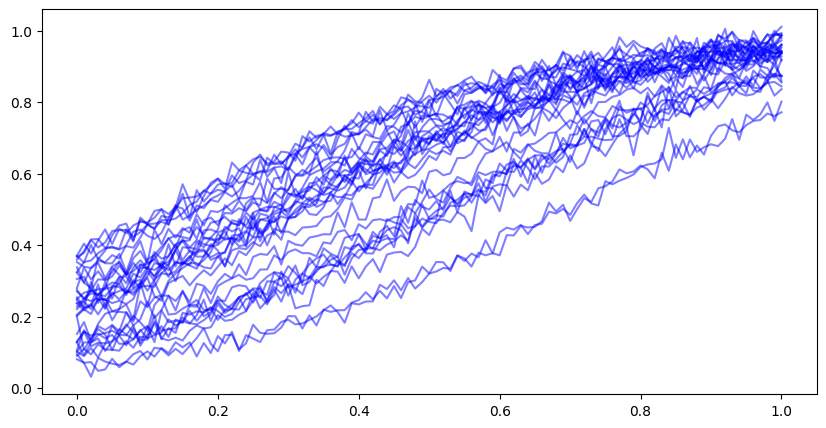

In [7]:
plt.figure(figsize=(10, 5))
for k in range(len(traj_train)):
    plt.plot(t_train[k], traj_train[k], alpha=0.5, color='blue')

In [13]:
traj_data_train = jnp.concatenate(traj_train, axis = 0)
data_std = jnp.std(traj_data_train, axis=0)
kernel = lambda x, y: kernels.gaussian_kernel_len_scales(x, y, len_scales=data_std)
lam = 0.02**2

In [14]:
def OCK_fit(traj: List[jnp.ndarray], t: List[jnp.ndarray], kernel: Callable, lam: float) -> Callable:
    '''Estimate the posterior Gaussian process vector field of trajectories using the OCK method.

    Get the posterior GP's mean and covariance.

    Args:
    traj: List of trajectory arrays.
    t: List of time arrays.
    kernel: Kernel function for the GP.
    lam: Regularization parameter.

    Returns:
    f_ock: Callable function representing the mean of the posterior GP.
    kernel_ock: Callable function representing the covariance of the posterior GP.
    '''

    delta_t = core.get_delta_t(t)
    delta_y = core.get_delta_y(traj)
    traj_idx = core.get_traj_idx(traj)
    traj_data = jnp.concatenate(traj, axis=0)
    K_mat = kernel(traj_data, traj_data)
    K_mat = K_mat[0:-1] + K_mat[1:]
    K_mat = K_mat[:, 0:-1] + K_mat[:, 1:]
    K_mat = K_mat[traj_idx]
    K_mat = K_mat[:, traj_idx]
    K_mat = delta_t[:, None] / 2.0 * delta_t[None, :] / 2.0 * K_mat
    gram_mat = K_mat + lam * jnp.eye(K_mat.shape[0])
    alpha = jnp.linalg.solve(gram_mat, delta_y)

    
    
    def make_L_x(x:jnp.ndarray, alpha: jnp.ndarray = alpha, kernel: Callable = kernel, traj_data: jnp.ndarray = traj_data, traj_idx: jnp.ndarray = traj_idx, delta_t: jnp.ndarray = delta_t) -> jnp.ndarray:
        K_mat = kernel(x, traj_data)
        K_mat = K_mat[:, 0:-1] + K_mat[:, 1:]
        K_mat = K_mat[:, traj_idx]
        K_mat = delta_t[None, :] / 2.0 * K_mat
        return K_mat

    def f_ock(x: jnp.ndarray, alpha: jnp.ndarray = alpha, kernel: Callable = kernel, traj_data: jnp.ndarray = traj_data, traj_idx: jnp.ndarray = traj_idx, delta_t: jnp.ndarray = delta_t) -> jnp.ndarray:
        L_x = make_L_x(x, alpha=alpha, kernel=kernel, traj_data=traj_data, traj_idx=traj_idx, delta_t=delta_t)
        return L_x @ alpha

    

    def kernel_ock(x: jnp.ndarray, y: jnp.ndarray, gram_mat: jnp.ndarray = gram_mat, kernel: Callable = kernel, traj_data: jnp.ndarray = traj_data, traj_idx: jnp.ndarray = traj_idx, delta_t: jnp.ndarray = delta_t) -> jnp.ndarray:
        L_x = make_L_x(x, alpha=alpha, kernel=kernel, traj_data=traj_data, traj_idx=traj_idx, delta_t=delta_t)
        L_y = make_L_x(y, alpha=alpha, kernel=kernel, traj_data=traj_data, traj_idx=traj_idx, delta_t=delta_t)
        K_mat = kernel(x, y)
        return K_mat - L_x@jnp.linalg.solve(gram_mat, L_y.T)

    return f_ock, kernel_ock
        

In [15]:
f_ock, kernel_ock = OCK_fit(traj_train, t_train, kernel, lam)

In [ ]:
kernel_ock(grid[0][None, :], grid[0][None, :])

(100,)


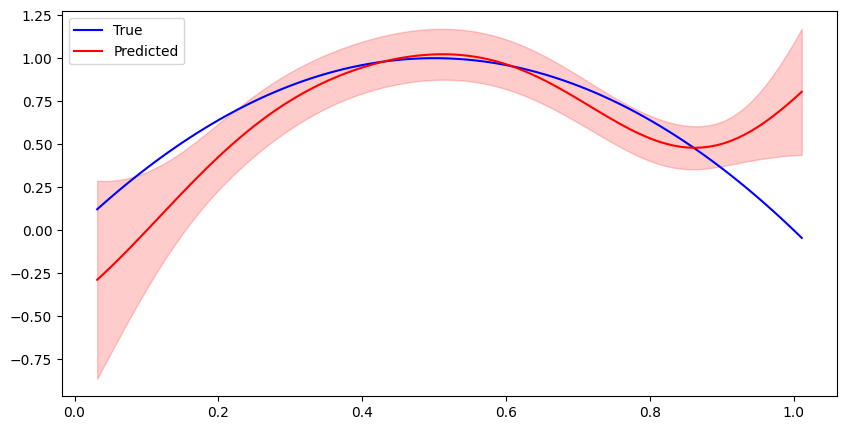

In [18]:
grid = jnp.linspace(jnp.min(traj_data_train), jnp.max(traj_data_train), num=100)[:, None]
plt.figure(figsize=(10, 5))
f_true = f(grid)
f_pred = f_ock(grid)
k_pred = [kernel_ock(grid[k][None, :], grid[k][None, :]) for k in range(grid.shape[0])]
k_pred = jnp.array(k_pred)[:, 0, 0]

print(k_pred.shape)
plt.plot(grid, f_true, color = 'blue', label = 'True')
plt.plot(grid, f_pred, color = 'red', label = 'Predicted')
f_pred = f_pred[:, 0]
plt.fill_between(grid[:, 0], f_pred - 1.96 * jnp.sqrt(k_pred), f_pred + 1.96 * jnp.sqrt(k_pred), color='red', alpha=0.2)
plt.legend()
plt.savefig('pictures/ock_pred_with_error_bars.pdf')

In [17]:
1.96*jnp.sqrt(k_pred)


Array([0.5752108 , 0.535589  , 0.49762496, 0.46147916, 0.4273075 ,
       0.39525363, 0.365445  , 0.33799365, 0.3129931 , 0.29049328,
       0.27052304, 0.2530583 , 0.23802005, 0.22527874, 0.2146504 ,
       0.205903  , 0.1987776 , 0.193005  , 0.18831156, 0.18444279,
       0.18118879, 0.17835607, 0.17581853, 0.17345053, 0.17119761,
       0.16901428, 0.16688468, 0.16480123, 0.16278395, 0.16085458,
       0.15903069, 0.15734217, 0.15580663, 0.15443827, 0.15324159,
       0.15222214, 0.15136683, 0.1506724 , 0.15011668, 0.1496821 ,
       0.14934288, 0.1490797 , 0.14887297, 0.14870214, 0.14854884,
       0.14840621, 0.14825957, 0.14809886, 0.14792171, 0.14772344,
       0.1474993 , 0.14724526, 0.14696118, 0.14664221, 0.1462834 ,
       0.14588058, 0.14542861, 0.14492626, 0.14437063, 0.14375553,
       0.14308977, 0.14236785, 0.14160344, 0.1408056 , 0.13998689,
       0.13915674, 0.1383473 , 0.13756555, 0.13683121, 0.13615598,
       0.13554499, 0.13500586, 0.13453014, 0.13408688, 0.13366